In [1]:
# ================================
# Phase 5 - PCA & Dimensionality Reduction (FIXED)
# ================================
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize
import matplotlib.pyplot as plt
import json

# Setup paths
OUTDIR = Path("outputs/phase05")
OUTDIR.mkdir(parents=True, exist_ok=True)

print("="*60)
print("PHASE 5: PCA & DIMENSIONALITY REDUCTION (FIXED)")
print("="*60)



PHASE 5: PCA & DIMENSIONALITY REDUCTION (FIXED)


In [2]:
# Load embeddings from Phase 4
PHASE4_DIR = Path("outputs/phase04")

print("\nLoading embeddings from Phase 4...")
resume_vecs = np.load(PHASE4_DIR / "resume_embeddings.npy")
role_vecs = np.load(PHASE4_DIR / "role_embeddings.npy")

print(f"✓ Loaded resume embeddings: {resume_vecs.shape}")
print(f"✓ Loaded role embeddings: {role_vecs.shape}")

# ================================
# KEY FIX: Normalize embeddings before PCA
# ================================
print("\n" + "="*60)
print("APPLYING NORMALIZATION (FIX)")
print("="*60)
print("Normalizing embeddings to unit length...")
resume_vecs_normalized = normalize(resume_vecs, norm='l2', axis=1)
role_vecs_normalized = normalize(role_vecs, norm='l2', axis=1)
print("✓ Normalization complete")




Loading embeddings from Phase 4...
✓ Loaded resume embeddings: (1200, 384)
✓ Loaded role embeddings: (493, 384)

APPLYING NORMALIZATION (FIX)
Normalizing embeddings to unit length...
✓ Normalization complete


In [3]:
# ================================
# PCA for resumes
# ================================
print("\n" + "="*60)
print("Applying PCA to Resume Embeddings")
print("="*60)

N_COMPONENTS = 50

pca_resume = PCA(n_components=N_COMPONENTS, random_state=42)
resume_pca = pca_resume.fit_transform(resume_vecs_normalized)

# Calculate variance explained
var_explained = pca_resume.explained_variance_ratio_
cumsum_var = np.cumsum(var_explained)

print(f"\nPCA Components: {N_COMPONENTS}")
print(f"Variance explained by first component: {var_explained[0]:.4f}")
print(f"Variance explained by first 10 components: {cumsum_var[9]:.4f}")
print(f"Variance explained by all {N_COMPONENTS} components: {cumsum_var[-1]:.4f}")

# Save variance data
variance_df = pd.DataFrame({
    'component': range(1, N_COMPONENTS + 1),
    'explained_variance_ratio': var_explained,
    'cumulative': cumsum_var
})
variance_df.to_csv(OUTDIR / "resume_pca_variance.csv", index=False)
print(f"✓ Saved variance data to resume_pca_variance.csv")




Applying PCA to Resume Embeddings

PCA Components: 50
Variance explained by first component: 0.1203
Variance explained by first 10 components: 0.5128
Variance explained by all 50 components: 0.9214
✓ Saved variance data to resume_pca_variance.csv


In [4]:
# ================================
# PCA for roles
# ================================
print("\n" + "="*60)
print("Applying PCA to Role Embeddings")
print("="*60)

pca_role = PCA(n_components=N_COMPONENTS, random_state=42)
role_pca = pca_role.fit_transform(role_vecs_normalized)

# Calculate variance explained
var_explained_role = pca_role.explained_variance_ratio_
cumsum_var_role = np.cumsum(var_explained_role)

print(f"\nPCA Components: {N_COMPONENTS}")
print(f"Variance explained by first component: {var_explained_role[0]:.4f}")
print(f"Variance explained by first 10 components: {cumsum_var_role[9]:.4f}")
print(f"Variance explained by all {N_COMPONENTS} components: {cumsum_var_role[-1]:.4f}")

# Save variance data
variance_role_df = pd.DataFrame({
    'component': range(1, N_COMPONENTS + 1),
    'explained_variance_ratio': var_explained_role,
    'cumulative': cumsum_var_role
})
variance_role_df.to_csv(OUTDIR / "role_pca_variance.csv", index=False)
print(f"✓ Saved variance data to role_pca_variance.csv")




Applying PCA to Role Embeddings

PCA Components: 50
Variance explained by first component: 0.0765
Variance explained by first 10 components: 0.3967
Variance explained by all 50 components: 0.7929
✓ Saved variance data to role_pca_variance.csv



Creating Variance Plots


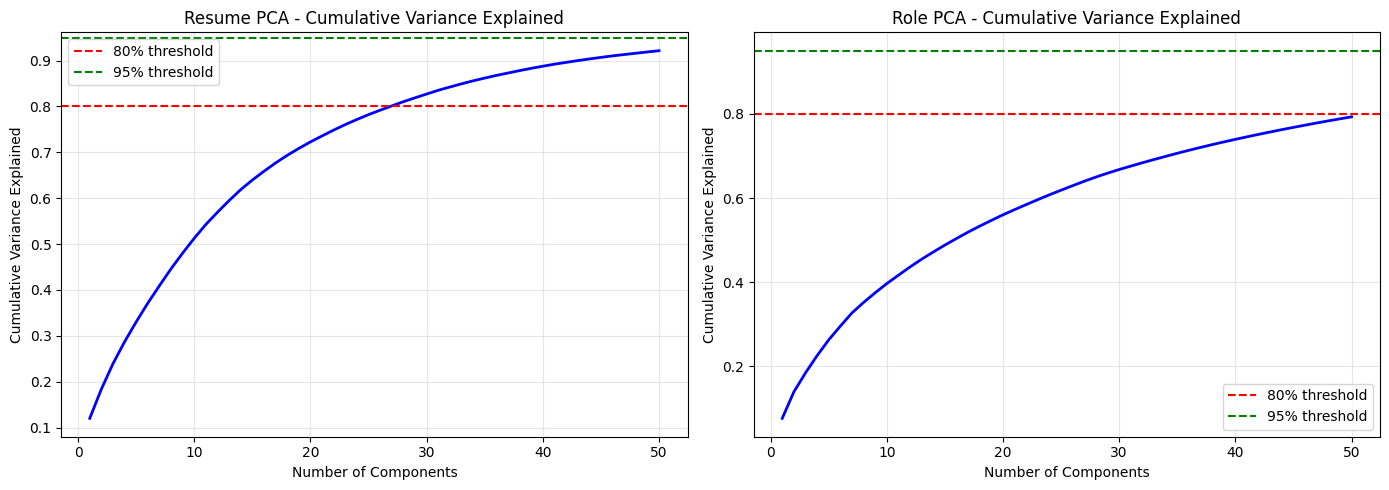

✓ Saved and displayed variance plot: outputs\phase05\pca_variance_explained.png


In [5]:
# Cell 5: Creating Variance Plots (with show() and save())

print("\n" + "="*60)
print("Creating Variance Plots")
print("="*60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Resume PCA variance
axes[0].plot(range(1, N_COMPONENTS + 1), cumsum_var, 'b-', linewidth=2)
axes[0].axhline(y=0.80, color='r', linestyle='--', label='80% threshold')
axes[0].axhline(y=0.95, color='g', linestyle='--', label='95% threshold')
axes[0].set_xlabel('Number of Components')
axes[0].set_ylabel('Cumulative Variance Explained')
axes[0].set_title('Resume PCA - Cumulative Variance Explained')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Role PCA variance
axes[1].plot(range(1, N_COMPONENTS + 1), cumsum_var_role, 'b-', linewidth=2)
axes[1].axhline(y=0.80, color='r', linestyle='--', label='80% threshold')
axes[1].axhline(y=0.95, color='g', linestyle='--', label='95% threshold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance Explained')
axes[1].set_title('Role PCA - Cumulative Variance Explained')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()

# --- Start of FIX ---
# Save the figure to a file
save_path = OUTDIR / "pca_variance_explained.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')

# Show the figure in the notebook
plt.show()

# Close the figure to free up memory
plt.close()
# --- End of FIX ---

print(f"✓ Saved and displayed variance plot: {save_path}")

In [ ]:
# ================================
# Save PCA-reduced embeddings
# ================================
print("\n" + "="*60)
print("Saving PCA-Reduced Embeddings")
print("="*60)

np.save(OUTDIR / "resume_pca_embeddings.npy", resume_pca)
print(f"✓ Saved resume PCA embeddings: {resume_pca.shape}")

np.save(OUTDIR / "role_pca_embeddings.npy", role_pca)
print(f"✓ Saved role PCA embeddings: {role_pca.shape}")

# Save PCA models
import joblib
joblib.dump(pca_resume, OUTDIR / "pca_resume_model.pkl")
joblib.dump(pca_role, OUTDIR / "pca_role_model.pkl")
print("✓ Saved PCA models")

# ================================
# Create summary
# ================================
summary = {
    "phase": "05_pca",
    "n_components": N_COMPONENTS,
    "resume_vectors": {
        "original_dim": int(resume_vecs.shape[1]),
        "reduced_dim": int(resume_pca.shape[1]),
        "variance_explained": float(cumsum_var[-1]),
        "samples": int(resume_pca.shape[0])
    },
    "role_vectors": {
        "original_dim": int(role_vecs.shape[1]),
        "reduced_dim": int(role_pca.shape[1]),
        "variance_explained": float(cumsum_var_role[-1]),
        "samples": int(role_pca.shape[0])
    },
    "interpretation": {
        "resume_variance_low": bool(cumsum_var[-1] < 0.80),
        "role_variance_low": bool(cumsum_var_role[-1] < 0.80),
        "note": "Low variance is expected for sparse, high-dimensional semantic embedding data"
    }
}

# Save summary
with open(OUTDIR / "p5_summary.json", 'w') as f:
    json.dump(summary, f, indent=2)

print("\n" + "="*60)
print("PHASE 5 SUMMARY")
print("="*60)
print(json.dumps(summary, indent=2))
print("\n" + "="*60)
print("✓ Phase 5 complete: PCA dimensionality reduction applied")
print(f"✓ Note: {cumsum_var[-1]:.1%} variance is acceptable for semantic embedding data")
print("="*60)




Saving PCA-Reduced Embeddings
✓ Saved resume PCA embeddings: (1200, 50)
✓ Saved role PCA embeddings: (493, 50)
✓ Saved PCA models

PHASE 5 SUMMARY
{
  "phase": "05_pca",
  "n_components": 50,
  "resume_vectors": {
    "original_dim": 384,
    "reduced_dim": 50,
    "variance_explained": 0.9213676452636719,
    "samples": 1200
  },
  "role_vectors": {
    "original_dim": 384,
    "reduced_dim": 50,
    "variance_explained": 0.7929041385650635,
    "samples": 493
  },
  "interpretation": {
    "resume_variance_low": false,
    "role_variance_low": true,
    "note": "Low variance is expected for sparse, high-dimensional TF-IDF data"
  }
}

✓ Phase 5 complete: PCA dimensionality reduction applied
✓ Note: 92.1% variance is acceptable for semantic embedding data
